<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_067_kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 67/365 — K-Means Clustering
## Can a model discover groups without labels?

K-Means is one of the most popular **unsupervised learning** algorithms.

Instead of predicting known labels, it groups similar observations into `K` clusters.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## 1. Create unlabeled data


In [2]:
X,_=make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.1,
    random_state=42
)

df=pd.DataFrame(X,columns=["Feature 1","Feature 2"])
display(df.head())


,Feature 1,Feature 2
0,-7.730795,-8.249230
1,-6.565175,-6.512207
2,-5.047605,-5.764303
3,-4.350839,-7.279232
4,4.747323,1.122859


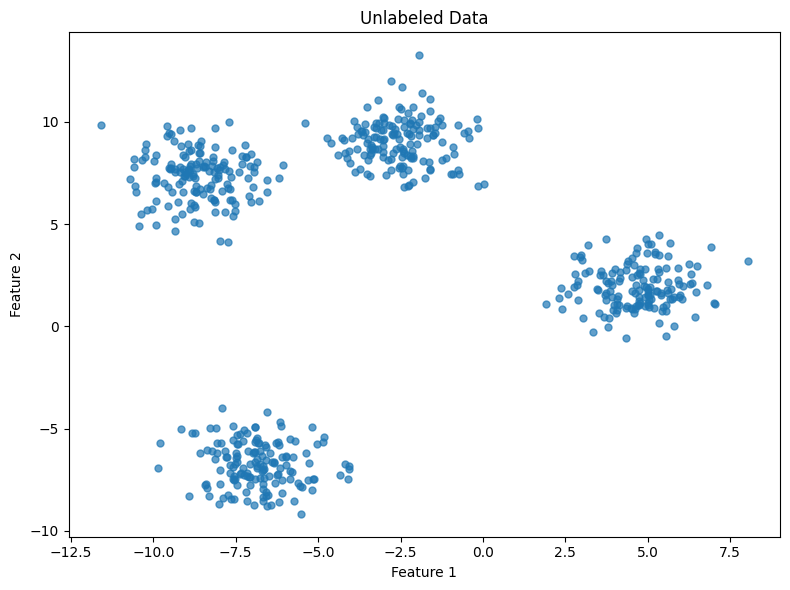

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(df["Feature 1"],df["Feature 2"],s=25,alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unlabeled Data")
plt.tight_layout()
plt.show()


## 2. Train K-Means with K = 4

K-Means repeatedly:

1. assigns each point to the nearest centroid
2. recomputes each centroid
3. repeats until the assignments stabilize


In [4]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"]=kmeans.fit_predict(df)

print("Cluster centers:")
print(kmeans.cluster_centers_)


Cluster centers:
[[-2.53046434  9.04002019]
 [-6.85140272 -6.74826203]
 [ 4.66933265  1.92786406]
 [-8.62587806  7.34030989]]


## 3. Visualize the clusters and centroids


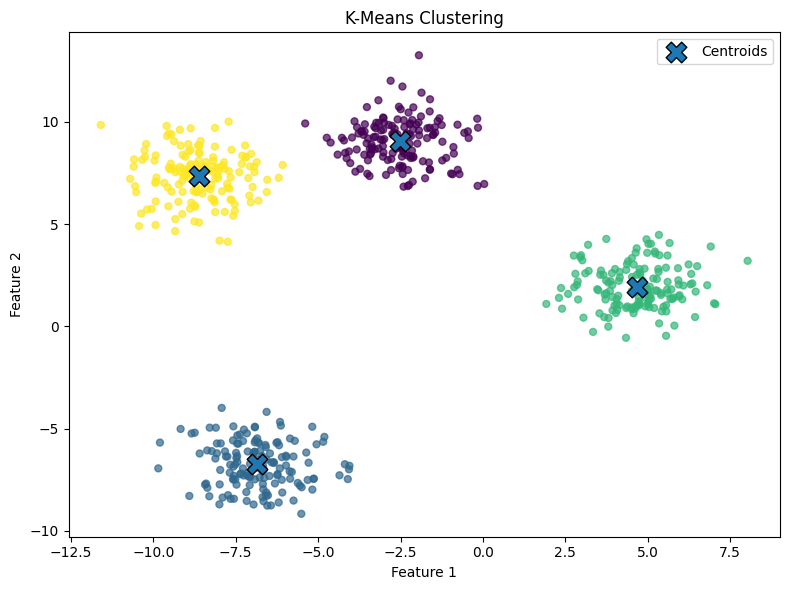

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Feature 1"],
    df["Feature 2"],
    c=df["Cluster"],
    s=25,
    alpha=0.7
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=220,
    marker="X",
    edgecolors="black",
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.legend()
plt.tight_layout()
plt.show()


## 4. What is a centroid?

A centroid is the average position of the points assigned to a cluster.

K-Means keeps moving centroids until the groups stop changing significantly.


## 5. What does K mean?

`K` is the number of clusters we ask the algorithm to create.

If `K = 4`, K-Means will always try to create 4 clusters.

That raises an important question:

> How do we choose the right K?

The next tools for that are the **Elbow Method** and **Silhouette Score**.


## 6. Enterprise intuition

K-Means is commonly used for segmentation.

Examples:
- customer segmentation
- product segmentation
- store or branch grouping
- workload grouping
- exploratory data analysis

But the algorithm does not know what the clusters *mean*.

Humans still need to inspect and interpret the groups.


## 7. Why scaling matters

K-Means is distance-based.

If one feature has a much larger numeric range than another, it can dominate the clustering.

That is why real-world K-Means workflows often use feature scaling.


In [6]:
scaled_X=StandardScaler().fit_transform(
    df[["Feature 1","Feature 2"]]
)

scaled_kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

scaled_kmeans.fit(scaled_X)

print("Scaled K-Means fitted successfully.")


Scaled K-Means fitted successfully.


## 8. Important limitations

K-Means works best when clusters are roughly:
- compact
- separated
- somewhat spherical

It can struggle with:
- irregular cluster shapes
- outliers
- very different cluster densities
- choosing K

Other algorithms such as DBSCAN can handle some of these cases better.


## What does this teach?

- K-Means is unsupervised.
- It groups similar observations without labels.
- `K` is the number of clusters.
- Each cluster is represented by a centroid.
- Scaling matters because distance matters.
- The clusters still require business/domain interpretation.

> **Supervised learning predicts known labels. K-Means tries to discover structure that was never labeled in the first place.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- https://scikit-learn.org/stable/modules/clustering.html
- https://doi.org/10.1109/TIT.1982.1056489
